# Exploratory Data Analysis — ISOT Fake News Dataset

Run this notebook after placing `Fake.csv` and `True.csv` inside the `data/` folder.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fake_df = pd.read_csv('../data/Fake.csv')
true_df = pd.read_csv('../data/True.csv')

fake_df['label'] = 0
true_df['label'] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [2]:
print('Total records:', len(df))
print(df['label'].value_counts())
print('\nMissing values:\n', df.isnull().sum())

Total records: 44898
label
0    23481
1    21417
Name: count, dtype: int64

Missing values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


## Class Balance

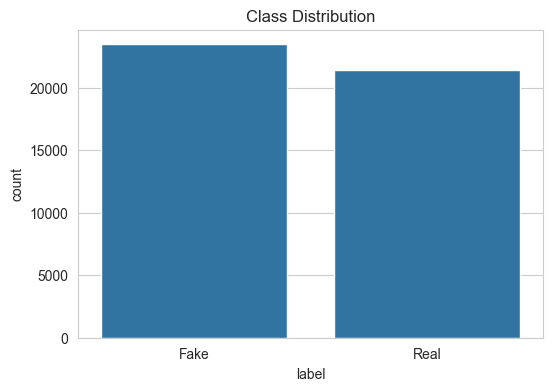

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Class Distribution')
plt.show()

## Article Length Distribution

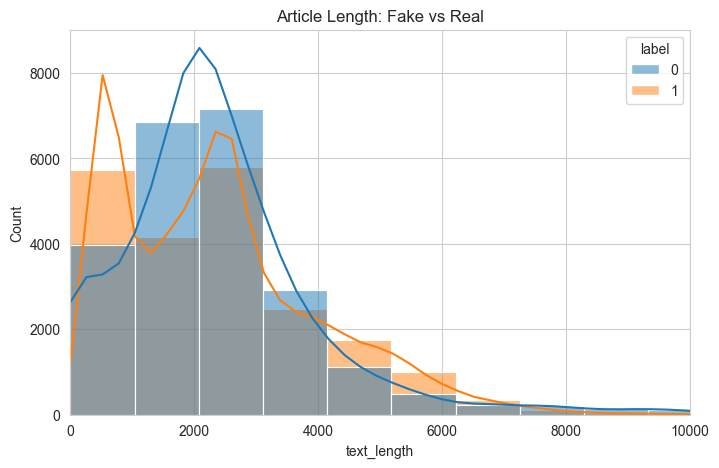

In [4]:
df['text_length'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Article Length: Fake vs Real')
plt.xlim(0, 10000)
plt.show()

## Subject / Category Breakdown (if `subject` column exists)

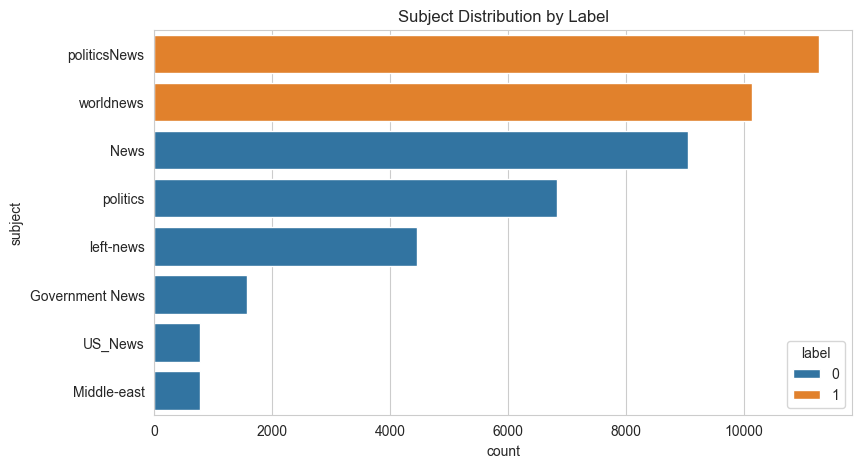

In [5]:
if 'subject' in df.columns:
    plt.figure(figsize=(9,5))
    sns.countplot(y='subject', hue='label', data=df, order=df['subject'].value_counts().index)
    plt.title('Subject Distribution by Label')
    plt.show()
else:
    print('No subject column found.')

## Most Common Words (Word Cloud style via frequency count)

In [6]:
import sys
sys.path.append('..')
from preprocessing import preprocess_text
from collections import Counter

sample = df.sample(2000, random_state=42)
sample['clean'] = sample['text'].astype(str).apply(preprocess_text)

all_words = ' '.join(sample['clean']).split()
common = Counter(all_words).most_common(20)
pd.DataFrame(common, columns=['word', 'count'])

,word,count
0,said,5993
1,trump,5900
2,state,2906
3,presid,2709
4,would,2525
5,year,1958
6,peopl,1875
7,one,1791
8,say,1667
9,republican,1653
